# 유저 관계·이용 행동과 다음 주 유지 분석

- 분석 목적: 어떤 관계 및 이용 행동을 보인 유저가 다음 주에도 서비스를 이용하는지 확인
- 기준 행동 기간: 2023-07-24 ~ 2023-07-30
- 유지 관찰 기간: 2023-07-31 ~ 2023-08-06
- 분석 단위: 유저 1명
- 유지 기준: 다음 주에 1회 이상 활동한 경우

## 1. 라이브러리 및 BigQuery 연결

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

pd.set_option("display.max_columns", None)

PROJECT_ID = "sns-analysis-prj"
DATASET_ID = "sns_analysis"
MART_TABLE = "mart_user_weekly_analysis"
LOCATION = "asia-northeast3"

MAX_BYTES = 1024**3

client = bigquery.Client(
    project=PROJECT_ID,
    location=LOCATION
)

/Users/apple/DA15_Part4/sns_service_analysis/.venv312/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [3]:
from pathlib import Path
from matplotlib import font_manager

# 운영체제별 한글 폰트 경로
font_paths = [
    "/System/Library/Fonts/AppleSDGothicNeo.ttc"             
]

for font_path in font_paths:
    if Path(font_path).exists():
        font_manager.fontManager.addfont(font_path)
        korean_font = font_manager.FontProperties(
            fname=font_path
        ).get_name()

        plt.rcParams["font.family"] = korean_font
        break

plt.rcParams["axes.unicode_minus"] = False

## 2. 분석 데이터 조회 쿼리

In [4]:
analysis_sql = f"""
SELECT
    user_id,
    week_start,
    signup_date,
    gender,
    group_id,
    school_id,
    grade,
    class_num,
    school_type,
    friend_count,
    active_days,
    event_count,
    session_count,
    question_start_count,
    question_complete_count,
    question_skip_count,
    received_vote_open_count,
    timeline_view_count,
    attendance_click_count,
    purchase_count,
    votes_given,
    unique_receivers,
    votes_received,
    unique_voters,
    top_voter_votes,
    received_concentration,
    active_classmates,
    next_week_retained
FROM `{PROJECT_ID}.{DATASET_ID}.{MART_TABLE}`
WHERE is_retention_eligible = 1
ORDER BY user_id
"""

## 3. 예상 조회 용량 확인

In [5]:
dry_run_config = bigquery.QueryJobConfig(
    dry_run=True,
    use_query_cache=False
)

dry_run_job = client.query(
    analysis_sql,
    job_config=dry_run_config
)

estimated_mb = dry_run_job.total_bytes_processed / 1024**2

print(f"예상 처리량: {estimated_mb:,.2f} MB")

예상 처리량: 54.38 MB


## 4. DataFrame으로 불러오기

In [6]:
job_config = bigquery.QueryJobConfig(
    maximum_bytes_billed=MAX_BYTES
)

df_raw = client.query(
    analysis_sql,
    job_config=job_config
).to_dataframe(create_bqstorage_client=False)

df = df_raw.copy()

df.head()

,user_id,week_start,signup_date,gender,group_id,school_id,grade,class_num,school_type,friend_count,active_days,event_count,session_count,question_start_count,question_complete_count,question_skip_count,received_vote_open_count,timeline_view_count,attendance_click_count,purchase_count,votes_given,unique_receivers,votes_received,unique_voters,top_voter_votes,received_concentration,active_classmates,next_week_retained
0,833041,2023-07-24,2023-03-31,F,149,314,3,1,H,29,2,24,1,0,0,0,0,5,2,0,0,0,0,0,0,NaN,0,1
1,833202,2023-07-24,2023-04-01,F,41,272,1,5,H,84,6,46,1,0,0,0,1,5,0,0,0,0,0,0,0,NaN,0,1
2,833203,2023-07-24,2023-04-01,M,42,272,1,9,H,72,1,31,1,0,0,0,7,5,0,0,0,0,1,1,1,1.0,2,1
3,833303,2023-07-24,2023-04-01,M,44,289,2,3,H,31,3,38,1,0,0,0,9,3,2,0,0,0,0,0,0,NaN,1,1
4,833525,2023-07-24,2023-04-01,F,39,281,1,8,H,105,1,36,1,0,0,0,2,6,1,0,0,0,0,0,0,NaN,5,0


## 5. 기본 구조 확인

In [7]:
df.shape

(117741, 28)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117741 entries, 0 to 117740
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   user_id                   117741 non-null  Int64  
 1   week_start                117741 non-null  dbdate 
 2   signup_date               115603 non-null  dbdate 
 3   gender                    115603 non-null  str    
 4   group_id                  115603 non-null  Int64  
 5   school_id                 115603 non-null  Int64  
 6   grade                     115603 non-null  Int64  
 7   class_num                 115603 non-null  Int64  
 8   school_type               115585 non-null  str    
 9   friend_count              117741 non-null  Int64  
 10  active_days               117741 non-null  Int64  
 11  event_count               117741 non-null  Int64  
 12  session_count             117741 non-null  Int64  
 13  question_start_count      117741 non-null  Int64  
 14 

In [9]:
print("고유 유저 수:", df["user_id"].nunique())

고유 유저 수: 117741


### 유저·주차 중복 재확인

In [10]:
df.duplicated(
    subset=["user_id", "week_start"]
).sum()

np.int64(0)

### 분석 주차 확인

In [11]:
df["week_start"].value_counts().sort_index()

week_start
2023-07-24    117741
Name: count, dtype: int64

## 6. 전체 다음 주 유지율

세부 행동별 차이를 비교하기 전에 전체 분석 대상의 다음 주 유지율을 기준값으로 확인한다.

In [12]:
total_users = len(df)
retained_users = int(df["next_week_retained"].sum())
overall_retention_rate = df["next_week_retained"].mean()

print(f"분석 대상 유저: {total_users:,}명")
print(f"다음 주 유지 유저: {retained_users:,}명")
print(f"전체 다음 주 유지율: {overall_retention_rate:.2%}")

분석 대상 유저: 117,741명
다음 주 유지 유저: 44,945명
전체 다음 주 유지율: 38.17%


## 7. 이용 행동과 다음 주 유지

해클 행동 로그를 기반으로 활동 빈도, 받은 질문 열람, 타임라인 및 출석 기능 이용과 다음 주 유지의 관계를 확인한다.

### 7-1. 활동일수별 유지율

기준 주차에 활동한 일수가 많을수록 다음 주 유지율이 높은지 확인한다.

In [13]:
# 활동일수 분포
active_days_distribution = (
    df["active_days"]
    .value_counts()
    .sort_index()
    .rename_axis("active_days")
    .reset_index(name="user_count")
)

active_days_distribution

,active_days,user_count
0,1,79333
1,2,21993
2,3,7601
3,4,3439
4,5,2055
5,6,1594
6,7,1726


In [14]:
# 활동일수별 유지율
active_days_retention = (
    df.groupby("active_days", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

active_days_retention

,active_days,user_count,retained_users,retention_rate
0,1,79333,22681,0.285896
1,2,21993,9800,0.445596
2,3,7601,4744,0.624128
3,4,3439,2680,0.779296
4,5,2055,1819,0.885158
5,6,1594,1515,0.950439
6,7,1726,1706,0.988413


In [15]:
# 백분율 표시 컬럼 생성
active_days_retention["retention_rate_pct"] = (
    active_days_retention["retention_rate"] * 100
).round(2)

active_days_retention

,active_days,user_count,retained_users,retention_rate,retention_rate_pct
0,1,79333,22681,0.285896,28.59
1,2,21993,9800,0.445596,44.56
2,3,7601,4744,0.624128,62.41
3,4,3439,2680,0.779296,77.93
4,5,2055,1819,0.885158,88.52
5,6,1594,1515,0.950439,95.04
6,7,1726,1706,0.988413,98.84


- 기준 주차의 활동일수가 늘어날수록 다음 주 유지율이 일관되게 증가했다.  
- 1일 활동 유저의 다음 주 유지율은 28.59%였지만, 3일 활동 유저는 62.41%, 7일 활동 유저는 98.84%로 나타났다.

- 활동일수와 다음 주 유지 사이에 강한 양의 관계가 확인되지만, 이미 서비스 이용 의지가 높은 유저가 자주 활동했을 가능성이 있으므로 인과관계로 해석하지 않는다.

#### 주 1일 이용자와 주 3일 이상 이용자 비교

세부 활동일수별 유지율을 확인한 결과를 바탕으로, 분석 질문에 맞게 유저를 1일, 2일, 3일 이상 활동 그룹으로 구분하여 유지율을 비교한다.

In [16]:
# 활동일수 구간 생성
df["active_days_group"] = np.select(
    [
        df["active_days"] == 1,
        df["active_days"] == 2,
        df["active_days"] >= 3
    ],
    [
        "1일",
        "2일",
        "3일 이상"
    ],
    default="기타"
)

In [17]:
# 구간별 유지율 계산
active_group_retention = (
    df.groupby("active_days_group", as_index=False)
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

active_group_retention["retention_rate_pct"] = (
    active_group_retention["retention_rate"] * 100
).round(2)

group_order = ["1일", "2일", "3일 이상"]

active_group_retention["active_days_group"] = pd.Categorical(
    active_group_retention["active_days_group"],
    categories=group_order,
    ordered=True
)

active_group_retention.sort_values("active_days_group")

,active_days_group,user_count,retained_users,retention_rate,retention_rate_pct
0,1일,79333,22681,0.285896,28.59
1,2일,21993,9800,0.445596,44.56
2,3일 이상,16415,12464,0.759306,75.93


In [18]:
# 1일 그룹과 3일 이상 그룹의 유지율 차이 계산
group_rates = active_group_retention.set_index(
    "active_days_group"
)["retention_rate_pct"]

retention_gap = (
    group_rates.loc["3일 이상"]
    - group_rates.loc["1일"]
)

print(f"1일 그룹 유지율: {group_rates.loc['1일']:.2f}%")
print(f"2일 그룹 유지율: {group_rates.loc['2일']:.2f}%")
print(f"3일 이상 그룹 유지율: {group_rates.loc['3일 이상']:.2f}%")
print(f"3일 이상과 1일 그룹의 차이: {retention_gap:.2f}%p")

1일 그룹 유지율: 28.59%
2일 그룹 유지율: 44.56%
3일 이상 그룹 유지율: 75.93%
3일 이상과 1일 그룹의 차이: 47.34%p


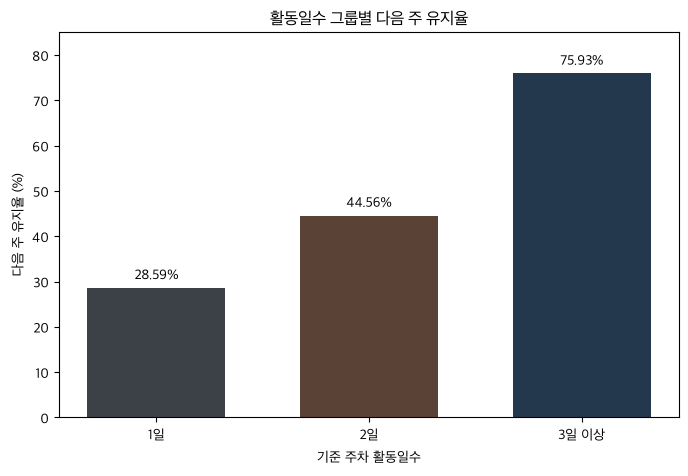

In [19]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    active_group_retention["active_days_group"].astype(str),
    active_group_retention["retention_rate_pct"],
    color=["#3C4147", "#5A4336", "#24384D"],
    width=0.65
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in active_group_retention["retention_rate_pct"]
    ],
    padding=3
)

plt.title("활동일수 그룹별 다음 주 유지율")
plt.xlabel("기준 주차 활동일수")
plt.ylabel("다음 주 유지율 (%)")
plt.ylim(0, 85)

plt.show()

- 기준 주차에 1일 활동한 유저의 다음 주 유지율은 28.59%, 2일 활동한 유저는 44.56%, 3일 이상 활동한 유저는 75.93%로 나타났다.
- 3일 이상 활동 그룹의 유지율은 1일 활동 그룹보다 47.34%p 높았다.
- 기준 주차의 활동 빈도가 높은 유저일수록 다음 주에도 활동하는 경향이 뚜렷하게 나타났다.
- 다만 서비스 이용 의지가 높은 유저가 기준 주차와 다음 주 모두 자주 활동했을 가능성이 있으므로 인과관계로 해석하지 않는다.

### 7-2. 받은 질문 열람 행동 여부별 유지율

기준 주차에 받은 질문 열람 이벤트가 한 번 이상 발생한 유저와 열람 이벤트가 발생하지 않은 유저의 다음 주 유지율을 비교한다.

열람한 질문이 기준 주차 이전에 받은 질문일 수 있으므로, 본 분석은 투표 수신 후 확인 전환율이 아니라 기준 주차의 받은 질문 열람 행동과 다음 주 유지의 관계를 확인하는 분석이다.

In [20]:
# 기준 주차에 받은 질문 열람 이벤트가 발생했는지 구분
question_open_order = [
    "열람 이벤트 없음",
    "열람 이벤트 있음"
]

df["received_question_open_group"] = pd.Categorical(
    np.where(
        df["received_vote_open_count"] > 0,
        "열람 이벤트 있음",
        "열람 이벤트 없음"
    ),
    categories=question_open_order,
    ordered=True
)

In [21]:
# 받은 질문 열람 행동 여부별 다음 주 유지율 계산
question_open_retention = (
    df.groupby(
        "received_question_open_group",
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

question_open_retention["user_share_pct"] = (
    question_open_retention["user_count"]
    / len(df)
    * 100
).round(2)

question_open_retention["retention_rate_pct"] = (
    question_open_retention["retention_rate"]
    * 100
).round(2)

question_open_retention

,received_question_open_group,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,열람 이벤트 없음,71125,24229,0.340654,60.41,34.07
1,열람 이벤트 있음,46616,20716,0.444397,39.59,44.44


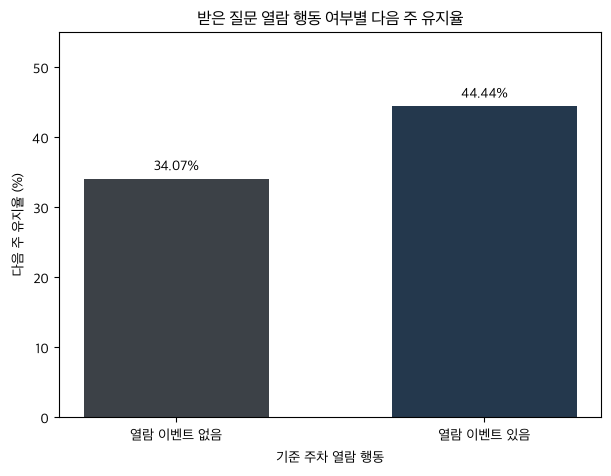

In [22]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    question_open_retention["received_question_open_group"].astype(str),
    question_open_retention["retention_rate_pct"],
    color=["#3C4147", "#24384D"],
    width=0.6
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in question_open_retention["retention_rate_pct"]
    ],
    padding=3
)

plt.title("받은 질문 열람 행동 여부별 다음 주 유지율")
plt.xlabel("기준 주차 열람 행동")
plt.ylabel("다음 주 유지율 (%)")
plt.ylim(0, 55)

plt.show()

- 받은 질문 열람 이벤트가 발생한 유저는 전체 분석 대상의 39.59%였으며, 다음 주 유지율은 44.44%로 열람 이벤트가 없었던 유저의 34.07%보다 10.37%p 높았다.

- 다만 열람 행동이 있었던 유저가 전반적으로 더 자주 활동한 유저일 수 있으므로, 활동일수 그룹이 같은 유저끼리 유지율을 추가로 비교한다.

#### 활동일수 그룹 내 받은 질문 열람 행동 여부 비교

전체 활동량의 영향을 일부 구분하기 위해 동일한 활동일수 그룹 안에서 받은 질문 열람 행동 여부별 다음 주 유지율을 비교한다.

In [23]:
# 활동일수가 같은 유저끼리 열람 행동 여부와 유지율 비교
open_retention_by_activity = (
    df.groupby(
        [
            "active_days_group",
            "received_question_open_group"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

open_retention_by_activity["retention_rate_pct"] = (
    open_retention_by_activity["retention_rate"]
    * 100
).round(2)

open_retention_by_activity

,active_days_group,received_question_open_group,user_count,retained_users,retention_rate,retention_rate_pct
0,1일,열람 이벤트 없음,54070,15217,0.281431,28.14
1,1일,열람 이벤트 있음,25263,7464,0.295452,29.55
2,2일,열람 이벤트 없음,11434,4971,0.434756,43.48
3,2일,열람 이벤트 있음,10559,4829,0.457335,45.73
4,3일 이상,열람 이벤트 없음,5621,4041,0.718911,71.89
5,3일 이상,열람 이벤트 있음,10794,8423,0.780341,78.03


In [24]:
open_retention_pivot = (
    open_retention_by_activity
    .pivot(
        index="active_days_group",
        columns="received_question_open_group",
        values="retention_rate_pct"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

open_retention_pivot["gap_pct_point"] = (
    open_retention_pivot["열람 이벤트 있음"]
    - open_retention_pivot["열람 이벤트 없음"]
).round(2)

open_retention_pivot.style.hide(axis="index")

active_days_group,열람 이벤트 없음,열람 이벤트 있음,gap_pct_point
1일,28.140000,29.550000,1.410000
2일,43.480000,45.730000,2.250000
3일 이상,71.890000,78.030000,6.140000


#### 분석 결과

전체 분석 대상 중 기준 주차에 받은 질문 열람 이벤트가 발생한 유저는 39.59%였다. 해당 유저의 다음 주 유지율은 44.44%로, 열람 이벤트가 없었던 유저의 34.07%보다 10.37%p 높았다.

활동일수가 같은 그룹 안에서 다시 비교한 결과는 다음과 같다.

- 1일 활동 그룹: 열람 이벤트 있음 그룹이 1.41%p 높음
- 2일 활동 그룹: 열람 이벤트 있음 그룹이 2.25%p 높음
- 3일 이상 활동 그룹: 열람 이벤트 있음 그룹이 6.14%p 높음

활동일수를 고려한 후에도 모든 그룹에서 열람 행동이 있었던 유저의 유지율이 더 높았다. 따라서 받은 질문 열람 행동은 다음 주 유지와 긍정적인 관계가 있는 것으로 나타났다.

다만 열람 이벤트가 없었던 유저에는 열람할 질문이 없었던 유저와 질문이 있었지만 열지 않은 유저가 함께 포함될 수 있다. 또한 투표 수신 시점과 열람 시점을 개별 투표 단위로 연결하지 않았으므로 기능의 인과 효과로 해석하지 않는다.

### 7-3. 타임라인 이용 여부별 유지율

기준 주차에 타임라인을 한 번 이상 이용한 유저와 이용하지 않은 유저의 다음 주 유지율을 비교한다.

In [25]:
# 기준 주차의 타임라인 이용 여부 구분
timeline_use_order = [
    "이용하지 않음",
    "이용함"
]

df["timeline_use_group"] = pd.Categorical(
    np.where(
        df["timeline_view_count"] > 0,
        "이용함",
        "이용하지 않음"
    ),
    categories=timeline_use_order,
    ordered=True
)

In [26]:
timeline_retention = (
    df.groupby(
        "timeline_use_group",
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

timeline_retention["user_share_pct"] = (
    timeline_retention["user_count"]
    / len(df)
    * 100
).round(2)

timeline_retention["retention_rate_pct"] = (
    timeline_retention["retention_rate"]
    * 100
).round(2)

timeline_retention

,timeline_use_group,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,이용하지 않음,32982,11895,0.360651,28.01,36.07
1,이용함,84759,33050,0.389929,71.99,38.99


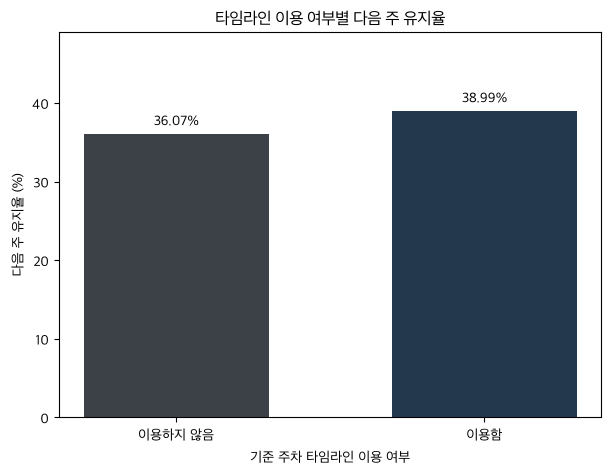

In [27]:
plt.figure(figsize=(7, 5))

bars = plt.bar(
    timeline_retention["timeline_use_group"].astype(str),
    timeline_retention["retention_rate_pct"],
    color=["#3C4147", "#24384D"],
    width=0.6
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.2f}%"
        for value in timeline_retention["retention_rate_pct"]
    ],
    padding=3
)

plt.title("타임라인 이용 여부별 다음 주 유지율")
plt.xlabel("기준 주차 타임라인 이용 여부")
plt.ylabel("다음 주 유지율 (%)")
plt.ylim(
    0,
    timeline_retention["retention_rate_pct"].max() + 10
)

plt.show()

#### 활동일수 그룹 내 타임라인 이용 여부 비교

타임라인 이용 유저가 전반적으로 더 자주 활동했을 가능성을 고려하여, 활동일수가 같은 그룹 안에서 타임라인 이용 여부별 다음 주 유지율을 비교한다.

In [28]:
timeline_retention_by_activity = (
    df.groupby(
        [
            "active_days_group",
            "timeline_use_group"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

timeline_retention_by_activity["retention_rate_pct"] = (
    timeline_retention_by_activity["retention_rate"]
    * 100
).round(2)

timeline_retention_by_activity

,active_days_group,timeline_use_group,user_count,retained_users,retention_rate,retention_rate_pct
0,1일,이용하지 않음,25796,8056,0.312296,31.23
1,1일,이용함,53537,14625,0.273176,27.32
2,2일,이용하지 않음,4752,2140,0.450337,45.03
3,2일,이용함,17241,7660,0.44429,44.43
4,3일 이상,이용하지 않음,2434,1699,0.698028,69.8
5,3일 이상,이용함,13981,10765,0.769974,77.0


In [29]:
timeline_retention_pivot = (
    timeline_retention_by_activity
    .pivot(
        index="active_days_group",
        columns="timeline_use_group",
        values="retention_rate_pct"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

timeline_retention_pivot["gap_pct_point"] = (
    timeline_retention_pivot["이용함"]
    - timeline_retention_pivot["이용하지 않음"]
).round(2)

timeline_retention_pivot.style.hide(axis="index")

active_days_group,이용하지 않음,이용함,gap_pct_point
1일,31.230000,27.320000,-3.910000
2일,45.030000,44.430000,-0.600000
3일 이상,69.800000,77.000000,7.200000


#### 분석 결과

전체 비교에서는 타임라인 이용 유저의 다음 주 유지율이 38.99%로, 이용하지 않은 유저의 36.07%보다 2.92%p 높았다.

그러나 활동일수가 같은 유저끼리 비교한 결과, 타임라인 이용 유저의 유지율은 1일 활동 그룹에서 3.91%p 낮았고, 2일 활동 그룹에서는 0.60%p 낮아 큰 차이가 없었다. 반면 3일 이상 활동 그룹에서는 타임라인 이용 유저의 유지율이 7.20%p 높았다.

따라서 타임라인 이용과 다음 주 유지의 관계는 모든 활동 그룹에서 일관되게 나타나지 않았다. 전체 비교에서 나타난 차이는 타임라인 이용 유저에 활동일수가 많은 유저가 더 많이 포함된 구성의 영향을 받은 것으로 볼 수 있다.

타임라인은 저활동 유저의 초기 유지를 높이는 행동이라기보다, 이미 반복적으로 활동하는 유저의 이용을 강화하는 행동일 가능성이 있다. 다만 본 결과는 행동과 유지의 관계를 비교한 것으로 인과관계로 해석하지 않는다.

### 7-4. 핵심 이용 행동 수별 유지율

질문 참여, 받은 질문 열람, 타임라인 이용 중 기준 주차에 몇 가지 행동을 경험했는지에 따라 다음 주 유지율을 비교한다.

여기서 행동 수가 0인 유저는 서비스에 전혀 활동하지 않은 유저가 아니라, 세 가지 핵심 행동이 기록되지 않은 유저를 의미한다.

In [30]:
# 세 가지 핵심 이용 행동의 발생 여부
df["used_question_start"] = (
    df["question_start_count"] > 0
).astype(int)

df["used_question_open"] = (
    df["received_vote_open_count"] > 0
).astype(int)

df["used_timeline"] = (
    df["timeline_view_count"] > 0
).astype(int)

# 기준 주차에 경험한 핵심 행동 종류 수
df["core_behavior_count"] = (
    df["used_question_start"]
    + df["used_question_open"]
    + df["used_timeline"]
)

In [31]:
#분포와 유지율 계산
# core_behavior_count [0: 선택한 세 행동 모두 없음, 1: 세 행동 중 1개 이용, 2: 세 행동 중 2개 이용, 3: 세 행동 모두 이용]
core_behavior_retention = (
    df.groupby(
        "core_behavior_count",
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

core_behavior_retention["user_share_pct"] = (
    core_behavior_retention["user_count"]
    / len(df)
    * 100
).round(2)

core_behavior_retention["retention_rate_pct"] = (
    core_behavior_retention["retention_rate"]
    * 100
).round(2)

core_behavior_retention

,core_behavior_count,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,0,22936,8007,0.349102,19.48,34.91
1,1,43536,13902,0.319322,36.98,31.93
2,2,34172,13641,0.399186,29.02,39.92
3,3,17097,9395,0.549512,14.52,54.95


핵심 행동 수별 유지율은 0개 34.91%, 1개 31.93%, 2개 39.92%, 3개 54.95%로 단순하게 증가하지 않았다.

특히 행동 1개 그룹의 유지율이 행동 없음 그룹보다 낮게 나타나, 행동 개수보다 어떤 행동을 이용했는지가 중요할 가능성이 있다. 따라서 구체적인 행동 조합별 유지율을 추가로 확인한다.

In [32]:
# 세 가지 핵심 행동의 구체적인 조합 생성
df["core_behavior_type"] = np.select(
    [
        (df["used_question_start"] == 0)
        & (df["used_question_open"] == 0)
        & (df["used_timeline"] == 0),

        (df["used_question_start"] == 1)
        & (df["used_question_open"] == 0)
        & (df["used_timeline"] == 0),

        (df["used_question_start"] == 0)
        & (df["used_question_open"] == 1)
        & (df["used_timeline"] == 0),

        (df["used_question_start"] == 0)
        & (df["used_question_open"] == 0)
        & (df["used_timeline"] == 1),

        (df["used_question_start"] == 1)
        & (df["used_question_open"] == 1)
        & (df["used_timeline"] == 0),

        (df["used_question_start"] == 1)
        & (df["used_question_open"] == 0)
        & (df["used_timeline"] == 1),

        (df["used_question_start"] == 0)
        & (df["used_question_open"] == 1)
        & (df["used_timeline"] == 1),

        (df["used_question_start"] == 1)
        & (df["used_question_open"] == 1)
        & (df["used_timeline"] == 1)
    ],
    [
        "선택 행동 없음",
        "질문 참여만",
        "받은 질문 열람만",
        "타임라인만",
        "질문 참여·받은 질문 열람",
        "질문 참여·타임라인",
        "받은 질문 열람·타임라인",
        "세 행동 모두"
    ],
    default="확인 필요"
)

In [33]:
behavior_type_retention = (
    df.groupby(
        "core_behavior_type",
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

behavior_type_retention["user_share_pct"] = (
    behavior_type_retention["user_count"]
    / len(df)
    * 100
).round(2)

behavior_type_retention["retention_rate_pct"] = (
    behavior_type_retention["retention_rate"]
    * 100
).round(2)

behavior_type_retention.sort_values(
    "retention_rate_pct",
    ascending=False
)

,core_behavior_type,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
3,세 행동 모두,17097,9395,0.549512,14.52,54.95
4,질문 참여·받은 질문 열람,2178,1021,0.468779,1.85,46.88
5,질문 참여·타임라인,10071,4191,0.416145,8.55,41.61
6,질문 참여만,2450,996,0.406531,2.08,40.65
0,받은 질문 열람·타임라인,21923,8429,0.384482,18.62,38.45
2,선택 행동 없음,22936,8007,0.349102,19.48,34.91
1,받은 질문 열람만,5418,1871,0.34533,4.60,34.53
7,타임라인만,35668,11035,0.309381,30.29,30.94


#### 활동일수 그룹 내 질문 참여 여부 비교

행동 조합별 비교에서 질문 참여가 포함된 그룹의 유지율이 일관되게 높게 나타났다. 전체 활동 빈도의 영향을 일부 구분하기 위해 활동일수가 같은 유저끼리 질문 참여 여부별 유지율을 비교한다.

In [34]:
question_participation_order = [
    "참여하지 않음",
    "참여함"
]

df["question_participation_group"] = pd.Categorical(
    np.where(
        df["question_start_count"] > 0,
        "참여함",
        "참여하지 않음"
    ),
    categories=question_participation_order,
    ordered=True
)

In [35]:
question_retention_by_activity = (
    df.groupby(
        [
            "active_days_group",
            "question_participation_group"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

question_retention_by_activity["retention_rate_pct"] = (
    question_retention_by_activity["retention_rate"]
    * 100
).round(2)

question_retention_by_activity

,active_days_group,question_participation_group,user_count,retained_users,retention_rate,retention_rate_pct
0,1일,참여하지 않음,63910,17818,0.278798,27.88
1,1일,참여함,15423,4863,0.315308,31.53
2,2일,참여하지 않음,14543,6225,0.428041,42.8
3,2일,참여함,7450,3575,0.479866,47.99
4,3일 이상,참여하지 않음,7492,5299,0.707288,70.73
5,3일 이상,참여함,8923,7165,0.802981,80.3


In [36]:
question_retention_pivot = (
    question_retention_by_activity
    .pivot(
        index="active_days_group",
        columns="question_participation_group",
        values="retention_rate_pct"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

question_retention_pivot["gap_pct_point"] = (
    question_retention_pivot["참여함"]
    - question_retention_pivot["참여하지 않음"]
).round(2)

question_retention_pivot.style.hide(axis="index")

active_days_group,참여하지 않음,참여함,gap_pct_point
1일,27.880000,31.530000,3.650000
2일,42.800000,47.990000,5.190000
3일 이상,70.730000,80.300000,9.570000


#### 분석 결과

전체 분석 대상 중 질문 참여를 시작한 유저는 31,796명으로 약 27.0%였으며, 나머지 약 73.0%에서는 질문 참여 행동이 발생하지 않았다. 타임라인 이용률이 71.99%였던 것과 비교하면, 다수의 유저가 직접 질문에 참여하기보다 타임라인 조회나 받은 질문 열람 등 수동적인 행동을 중심으로 서비스를 이용한 것으로 볼 수 있다.

활동일수가 같은 유저끼리 비교해도 질문 참여 유저의 다음 주 유지율은 1일 활동 그룹에서 3.65%p, 2일 활동 그룹에서 5.19%p, 3일 이상 활동 그룹에서 9.57%p 높았다.

따라서 질문 참여는 다음 주 유지와 일관되게 긍정적인 관계를 보이는 핵심 행동 후보로 판단된다. 서비스 관점에서는 열람 중심 유저가 첫 질문 참여로 전환하도록 유도하는 것이 유지 개선 기회가 될 수 있다.

다만 서비스 이용 의지가 높은 유저가 질문 참여와 다음 주 활동을 모두 적극적으로 수행했을 가능성이 있으므로 인과관계로 해석하지 않는다.

### 7-5. 출석 클릭 여부별 유지율

기준 주차에 출석 기능을 한 번 이상 클릭한 유저와 클릭하지 않은 유저의 다음 주 유지율을 비교한다.

In [37]:
# 그룹 생성
attendance_click_order = [
    "출석 클릭 O",
    "출석 클릭 X"
]

df["attendance_click_group"] = pd.Categorical(
    np.where(
        df["attendance_click_count"] > 0,
        "출석 클릭 O",
        "출석 클릭 X"
    ),
    categories=attendance_click_order,
    ordered=True
)

In [38]:
attendance_retention = (
    df.groupby(
        "attendance_click_group",
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

attendance_retention["user_share_pct"] = (
    attendance_retention["user_count"]
    / df["user_id"].nunique()
    * 100
).round(2)

attendance_retention["retention_rate_pct"] = (
    attendance_retention["retention_rate"]
    * 100
).round(2)

attendance_retention

,attendance_click_group,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,출석 클릭 O,21377,11987,0.560743,18.16,56.07
1,출석 클릭 X,96364,32958,0.342016,81.84,34.2


#### 활동일수 그룹 내 출석 클릭 여부 비교

출석 기능을 클릭한 유저가 전반적으로 더 자주 활동했을 가능성을 고려하여, 활동일수가 같은 유저끼리 출석 클릭 여부별 다음 주 유지율을 비교한다.

In [39]:
attendance_retention_by_activity = (
    df.groupby(
        [
            "active_days_group",
            "attendance_click_group"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

attendance_retention_by_activity["retention_rate_pct"] = (
    attendance_retention_by_activity["retention_rate"]
    * 100
).round(2)

attendance_retention_by_activity

,active_days_group,attendance_click_group,user_count,retained_users,retention_rate,retention_rate_pct
0,1일,출석 클릭 O,9040,3214,0.355531,35.55
1,1일,출석 클릭 X,70293,19467,0.276941,27.69
2,2일,출석 클릭 O,4970,2574,0.517907,51.79
3,2일,출석 클릭 X,17023,7226,0.424485,42.45
4,3일 이상,출석 클릭 O,7367,6199,0.841455,84.15
5,3일 이상,출석 클릭 X,9048,6265,0.692418,69.24


In [40]:
attendance_retention_pivot = (
    attendance_retention_by_activity
    .pivot(
        index="active_days_group",
        columns="attendance_click_group",
        values="retention_rate_pct"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

attendance_retention_pivot["gap_pct_point"] = (
    attendance_retention_pivot["출석 클릭 O"]
    - attendance_retention_pivot["출석 클릭 X"]
).round(2)

attendance_retention_pivot.style.hide(axis="index")

active_days_group,출석 클릭 O,출석 클릭 X,gap_pct_point
1일,35.550000,27.690000,7.860000
2일,51.790000,42.450000,9.340000
3일 이상,84.150000,69.240000,14.910000


#### 분석 결과

전체 비교에서 출석 클릭 유저의 다음 주 유지율은 56.07%로, 출석을 클릭하지 않은 유저의 34.20%보다 21.87%p 높았다.

활동일수가 같은 유저끼리 비교한 결과에서도 출석 클릭 유저의 유지율은 1일 활동 그룹에서 7.86%p, 2일 활동 그룹에서 9.34%p, 3일 이상 활동 그룹에서 14.91%p 높았다.

따라서 출석 클릭은 단순히 활동일수가 많은 유저에게서 자주 발생하는 행동일 뿐만 아니라, 활동 빈도를 일부 고려한 후에도 다음 주 유지와 강한 관계를 보이는 행동으로 나타났다. 출석 기능은 유저의 반복 방문 습관을 형성하거나, 이미 이용 습관이 형성된 유저를 보여주는 주요 행동 지표일 가능성이 있다.

다만 출석 클릭이 유지율을 직접 높였다고 단정할 수는 없으며, 서비스 이용 의지가 높은 유저가 출석 기능도 적극적으로 이용했을 가능성을 고려해야 한다.

## 8. 유저 관계와 다음 주 유지

내부 회원 및 행동 데이터를 기반으로 같은 학급의 활성 유저 수, 투표 교류 형태 등 유저 관계와 다음 주 유지의 관계를 확인한다.

학교 테이블의 `student_count`는 실제 재학생 수인지 서비스 내부 누적 유저 수인지 정의가 불명확하여 사용하지 않는다. 대신 기준 주차에 같은 학급에서 실제로 활동한 다른 유저 수를 나타내는 `active_classmates`를 사용한다.

### 8-1. 관계 분석 대상 확인

해클 유저와 내부 회원 테이블이 연결되지 않은 경우 관계 지표의 0이 실제 관계 없음이 아니라 데이터 미연결을 의미할 수 있다.

따라서 내부 회원의 가입일을 확인할 수 있는 유저만 관계 분석 대상으로 사용하고, 해당 유저들의 학급 정보 누락 여부를 함께 확인한다.

In [41]:
# 내부 회원 정보와 연결된 유저만 관계 분석 대상으로 사용
relation_df = df[
    df["signup_date"].notna()
].copy()

total_user_count = df["user_id"].nunique()
relation_user_count = relation_df["user_id"].nunique()
missing_group_users = relation_df["group_id"].isna().sum()

print(f"전체 분석 유저: {total_user_count:,}명")
print(f"관계 분석 가능 유저: {relation_user_count:,}명")
print(
    f"관계 분석 대상 비율: "
    f"{relation_user_count / total_user_count:.2%}"
)
print(
    f"관계 분석 대상 유지율: "
    f"{relation_df['next_week_retained'].mean():.2%}"
)
print(f"관계 분석 대상 중 학급 정보 누락: {missing_group_users:,}명")

전체 분석 유저: 117,741명
관계 분석 가능 유저: 115,603명
관계 분석 대상 비율: 98.18%
관계 분석 대상 유지율: 38.26%
관계 분석 대상 중 학급 정보 누락: 0명


- 내부 회원 정보와 연결된 관계 분석 대상은 115,603명으로 전체 분석 대상의 98.18%였다. 관계 분석 대상의 다음 주 유지율은 38.26%로 전체 유지율 38.17%와 거의 동일했다.
- 또한 관계 분석 대상의 학급 정보 누락은 0건으로 확인되어, 동일한 분석 대상을 활성 동급생 분석에 사용한다.

### 8-2. 같은 학급의 주간 활성 유저 수와 다음 주 유지

`active_classmates`는 학교 또는 학급의 전체 가입자 수가 아니라, 기준 주차에 같은 `group_id`에서 실제로 활동한 다른 유저 수를 의미한다.

따라서 본 분석은 서비스 실행 조건에 필요한 가입자 수를 확인하는 분석이 아니라, 같은 기간에 함께 활동한 동급생 규모와 다음 주 유지의 관계를 확인하는 분석이다.

In [42]:
active_classmates_summary = (
    relation_df["active_classmates"]
    .describe(
        percentiles=[
            0.25,
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
    .to_frame(name="active_classmates")
)

active_classmates_summary

,active_classmates
count,115603.0
mean,3.154607
std,2.801964
min,0.0
25%,1.0
50%,3.0
75%,5.0
90%,7.0
95%,8.0
99%,12.0


- 활성 동급생 수의 중앙값은 3명이었으며, 전체 유저의 75%는 활성 동급생이 5명 이하로 나타났다. 분포를 고려하여 0명, 1~2명, 3~5명, 6명 이상으로 구분한다.

In [43]:
classmate_group_order = [
    "0명",
    "1~2명",
    "3~5명",
    "6명 이상"
]

relation_df["active_classmates_group"] = pd.cut(
    relation_df["active_classmates"],
    bins=[-1, 0, 2, 5, np.inf],
    labels=classmate_group_order
)

In [44]:
classmate_retention = (
    relation_df.groupby(
        "active_classmates_group",
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

classmate_retention["user_share_pct"] = (
    classmate_retention["user_count"]
    / relation_user_count
    * 100
).round(2)

classmate_retention["retention_rate_pct"] = (
    classmate_retention["retention_rate"]
    * 100
).round(2)

classmate_retention

,active_classmates_group,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,0명,16841,5675,0.336975,14.57,33.7
1,1~2명,39716,14011,0.35278,34.36,35.28
2,3~5명,39463,15206,0.385323,34.14,38.53
3,6명 이상,19583,9337,0.476791,16.94,47.68


- 같은 학급의 주간 활성 유저 수가 많을수록 다음 주 유지율이 일관되게 증가했다. 활성 동급생이 0명인 유저의 유지율은 33.70%였지만, 6명 이상인 유저는 47.68%로 13.98%p 높았다.

- 이는 같은 학급에서 함께 활동하는 유저가 많은 환경일수록 다음 주에도 서비스를 이용하는 경향이 강하다는 것을 보여준다. 다만 학급 전체 가입자 수나 서비스 실행 가능 여부를 나타내는 결과는 아니며, 학급의 전반적인 활성도와 개인의 서비스 이용 의지가 함께 반영됐을 가능성이 있다.

#### 활동일수 그룹 내 활성 동급생 수 비교

활성 동급생이 많은 유저가 본인도 더 자주 활동했을 가능성을 고려하여, 활동일수가 같은 유저끼리 활성 동급생 수에 따른 다음 주 유지율을 비교한다.

In [45]:
classmate_retention_by_activity = (
    relation_df.groupby(
        [
            "active_days_group",
            "active_classmates_group"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

classmate_retention_by_activity["retention_rate_pct"] = (
    classmate_retention_by_activity["retention_rate"]
    * 100
).round(2)

classmate_retention_by_activity

,active_days_group,active_classmates_group,user_count,retained_users,retention_rate,retention_rate_pct
0,1일,0명,12710,3436,0.270338,27.03
1,1일,1~2명,28418,7897,0.277887,27.79
2,1일,3~5명,26031,7531,0.289309,28.93
3,1일,6명 이상,10622,3430,0.322915,32.29
4,2일,0명,2601,1114,0.428297,42.83
5,2일,1~2명,7075,3052,0.431378,43.14
6,2일,3~5명,7863,3486,0.443342,44.33
7,2일,6명 이상,4120,2011,0.488107,48.81
8,3일 이상,0명,1530,1125,0.735294,73.53
9,3일 이상,1~2명,4223,3062,0.725077,72.51


In [46]:
classmate_retention_pivot = (
    classmate_retention_by_activity
    .pivot(
        index="active_days_group",
        columns="active_classmates_group",
        values="retention_rate_pct"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

classmate_retention_pivot["6명 이상과 0명 차이"] = (
    classmate_retention_pivot["6명 이상"]
    - classmate_retention_pivot["0명"]
).round(2)

classmate_retention_pivot.style.hide(axis="index")

active_days_group,0명,1~2명,3~5명,6명 이상,6명 이상과 0명 차이
1일,27.030000,27.790000,28.930000,32.290000,5.260000
2일,42.830000,43.140000,44.330000,48.810000,5.980000
3일 이상,73.530000,72.510000,75.220000,80.480000,6.950000


#### 분석 결과

전체 비교에서 같은 학급의 주간 활성 동급생 수가 많을수록 다음 주 유지율이 전반적으로 증가했다. 활성 동급생이 0명인 유저의 유지율은 33.70%였으며, 6명 이상인 유저는 47.68%로 13.98%p 높았다.

본인의 활동 빈도에 따른 영향을 일부 구분하기 위해 활동일수가 같은 유저끼리 다시 비교한 결과, 활성 동급생 6명 이상 그룹의 유지율은 0명 그룹보다 다음과 같이 높았다.

- 1일 활동 그룹: 5.26%p 높음
- 2일 활동 그룹: 5.98%p 높음
- 3일 이상 활동 그룹: 6.95%p 높음

따라서 본인의 활동일수가 같더라도 같은 학급에서 함께 활동하는 유저가 많은 경우 다음 주 유지율이 더 높은 경향이 확인되었다. 이는 서비스 이용에서 주변 동급생의 동시 활동성이 개인의 반복 방문과 관계가 있을 가능성을 보여준다.

다만 `active_classmates`는 학급 전체 가입자 수나 서비스 실행 조건을 나타내는 값이 아니라, 기준 주차에 같은 학급에서 실제 활동한 다른 유저 수를 의미한다. 또한 학급의 전반적인 활성도와 개별 유저의 이용 의지가 함께 반영됐을 수 있으므로 인과관계로 해석하지 않는다.

### 8-3. 투표 관계 데이터 활용 가능성 점검

내부 투표 기록을 유지 분석에 활용할 수 있는지 확인한다. 먼저 기준 주차의 투표 참여 형태와 표본 규모를 확인하고, 표본이 부족할 경우 결과 기간 이전의 누적 투표 이력까지 범위를 확장한다.

#### 기준 주차 투표 참여 형태

`votes_given`은 기준 주차에 다른 유저에게 투표한 횟수이며, `votes_received`는 기준 주차에 다른 유저에게 투표받은 횟수를 의미한다.

In [47]:
vote_activity_order = [
    "투표 기록 없음",
    "투표만 함",
    "투표만 받음",
    "투표하고 받음"
]

relation_df["vote_activity_group"] = pd.Categorical(
    np.select(
        [
            (relation_df["votes_given"] == 0)
            & (relation_df["votes_received"] == 0),

            (relation_df["votes_given"] > 0)
            & (relation_df["votes_received"] == 0),

            (relation_df["votes_given"] == 0)
            & (relation_df["votes_received"] > 0),

            (relation_df["votes_given"] > 0)
            & (relation_df["votes_received"] > 0)
        ],
        vote_activity_order,
        default="확인 필요"
    ),
    categories=vote_activity_order,
    ordered=True
)

In [48]:
vote_activity_retention = (
    relation_df.groupby(
        "vote_activity_group",
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

vote_activity_retention["user_share_pct"] = (
    vote_activity_retention["user_count"]
    / relation_df["user_id"].nunique()
    * 100
).round(2)

vote_activity_retention["retention_rate_pct"] = (
    vote_activity_retention["retention_rate"]
    * 100
).round(2)

vote_activity_retention

,vote_activity_group,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,투표 기록 없음,115436,44149,0.382454,99.86,38.25
1,투표만 함,58,28,0.482759,0.05,48.28
2,투표만 받음,99,45,0.454545,0.09,45.45
3,투표하고 받음,10,7,0.7,0.01,70.0


In [49]:
print(
    "그룹별 유저 수 합:",
    vote_activity_retention["user_count"].sum()
)

print(
    "관계 분석 전체 유저:",
    relation_df["user_id"].nunique()
)

print(
    "유저 비중 합:",
    vote_activity_retention["user_share_pct"].sum()
)

그룹별 유저 수 합: 115603
관계 분석 전체 유저: 115603
유저 비중 합: 100.01


#### 기준 주차 분석 결과

관계 분석 대상 115,603명 중 기준 주차에 투표 기록이 없는 유저는 115,436명으로 99.86%를 차지했다. 투표 기록이 있는 유저는 167명으로 전체의 약 0.14%에 불과했다.

투표 기록이 있는 그룹의 유지율이 상대적으로 높게 나타났지만, 각 그룹의 표본이 매우 작아 일반적인 관계로 해석하기 어렵다.

따라서 기준 주차 기록만으로 투표 관계를 분석하지 않고, 시간 누수를 방지하기 위해 결과 기간이 시작되기 전인 2023년 7월 30일까지의 누적 투표 이력으로 범위를 확장한다.

In [50]:
prior_vote_sql = f"""
WITH retention_cohort AS (
    SELECT DISTINCT
        user_id
    FROM `{PROJECT_ID}.{DATASET_ID}.{MART_TABLE}`
    WHERE is_retention_eligible = 1
      AND signup_date IS NOT NULL
),

prior_vote_records AS (
    SELECT
        SAFE_CAST(user_id AS INT64) AS voter_user_id,
        SAFE_CAST(chosen_user_id AS INT64) AS receiver_user_id
    FROM `{PROJECT_ID}.{DATASET_ID}.accounts_userquestionrecord`
    WHERE DATE(created_at, 'Asia/Seoul')
          <= DATE '2023-07-30'
      AND SAFE_CAST(user_id AS INT64) IS NOT NULL
      AND SAFE_CAST(chosen_user_id AS INT64) IS NOT NULL
),

prior_votes_given AS (
    SELECT
        voter_user_id AS user_id,
        COUNT(*) AS prior_votes_given,
        COUNT(DISTINCT receiver_user_id)
            AS prior_unique_receivers
    FROM prior_vote_records
    GROUP BY user_id
),

prior_votes_received AS (
    SELECT
        receiver_user_id AS user_id,
        COUNT(*) AS prior_votes_received,
        COUNT(DISTINCT voter_user_id)
            AS prior_unique_voters
    FROM prior_vote_records
    GROUP BY user_id
)

SELECT
    c.user_id,
    COALESCE(g.prior_votes_given, 0)
        AS prior_votes_given,
    COALESCE(g.prior_unique_receivers, 0)
        AS prior_unique_receivers,
    COALESCE(r.prior_votes_received, 0)
        AS prior_votes_received,
    COALESCE(r.prior_unique_voters, 0)
        AS prior_unique_voters
FROM retention_cohort AS c
LEFT JOIN prior_votes_given AS g
    ON c.user_id = g.user_id
LEFT JOIN prior_votes_received AS r
    ON c.user_id = r.user_id
"""

In [51]:
prior_vote_df = client.query(
    prior_vote_sql,
    job_config=job_config
).to_dataframe(create_bqstorage_client=False)

prior_vote_df.head()

,user_id,prior_votes_given,prior_unique_receivers,prior_votes_received,prior_unique_voters
0,1579542,0,0,0,0
1,1341587,0,0,0,0
2,1446852,0,0,0,0
3,1379563,0,0,0,0
4,841271,0,0,0,0


In [52]:
has_prior_vote = (
    (prior_vote_df["prior_votes_given"] > 0)
    | (prior_vote_df["prior_votes_received"] > 0)
)

prior_vote_user_count = int(has_prior_vote.sum())
prior_vote_user_share = has_prior_vote.mean()

print(f"과거 투표 경험 유저: {prior_vote_user_count:,}명")
print(f"과거 투표 경험 유저 비율: {prior_vote_user_share:.2%}")

과거 투표 경험 유저: 1,902명
과거 투표 경험 유저 비율: 1.65%


#### 과거 투표 관계 경험과 다음 주 유지

기준 주차의 투표 기록만 사용할 경우 투표 경험 유저가 매우 적어, 결과 기간이 시작되기 전인 2023년 7월 30일까지의 내부 투표 이력을 사용한다.

과거에 투표하거나 투표받은 경험이 한 번이라도 있는 유저와 경험이 없는 유저의 다음 주 유지율을 비교한다.

In [53]:
# 셀을 다시 실행해도 중복 컬럼이 생기지 않도록 기존 컬럼 제거
prior_vote_columns = [
    "prior_votes_given",
    "prior_unique_receivers",
    "prior_votes_received",
    "prior_unique_voters"
]

relation_df = relation_df.drop(
    columns=prior_vote_columns,
    errors="ignore"
)

relation_df = relation_df.merge(
    prior_vote_df,
    on="user_id",
    how="left",
    validate="one_to_one"
)

In [54]:
prior_vote_experience_order = [
    "과거 투표 경험 없음",
    "과거 투표 경험 있음"
]

relation_df["prior_vote_experience_group"] = pd.Categorical(
    np.where(
        (relation_df["prior_votes_given"] > 0)
        | (relation_df["prior_votes_received"] > 0),
        "과거 투표 경험 있음",
        "과거 투표 경험 없음"
    ),
    categories=prior_vote_experience_order,
    ordered=True
)

In [55]:
prior_vote_retention = (
    relation_df.groupby(
        "prior_vote_experience_group",
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

prior_vote_retention["user_share_pct"] = (
    prior_vote_retention["user_count"]
    / relation_df["user_id"].nunique()
    * 100
).round(2)

prior_vote_retention["retention_rate_pct"] = (
    prior_vote_retention["retention_rate"]
    * 100
).round(2)

prior_vote_retention

,prior_vote_experience_group,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,과거 투표 경험 없음,113701,43569,0.383189,98.35,38.32
1,과거 투표 경험 있음,1902,660,0.347003,1.65,34.7


#### 최종 판단

기준 주차에 투표 기록이 있는 유저는 167명으로 관계 분석 대상의 약 0.14%에 불과했다. 결과 기간 이전의 누적 투표 이력으로 범위를 확장해도 투표 경험 유저는 1,902명으로 전체의 1.65%였다.

과거 투표 경험 유저의 다음 주 유지율은 34.70%로, 경험이 없는 유저의 38.32%보다 3.62%p 낮았다. 이는 투표 경험이 다음 주 유지와 긍정적인 관계가 있을 것이라는 예상과 다른 결과였다.

다만 투표 경험 유저의 비중이 매우 작고, 해당 그룹에는 이전부터 서비스를 사용한 기존 유저의 특성이 반영됐을 가능성이 있다. 따라서 투표 경험이 유지율을 낮춘다고 해석하지 않으며, 투표 교류 상대 수와 집중도에 대한 추가 분석은 진행하지 않는다.

### 8-4. 관계 분석 요약

- 내부 회원 정보와 연결된 유저는 전체 분석 대상의 98.18%였으며, 전체 유지율과 관계 분석 대상의 유지율은 거의 동일했다.
- 같은 학급에서 기준 주차에 함께 활동한 유저가 많을수록 다음 주 유지율이 높은 경향이 나타났다.
- 활동일수가 같은 유저끼리 비교해도 활성 동급생 6명 이상 그룹은 0명 그룹보다 유지율이 5.26~6.95%p 높았다.
- 실제 투표 관계 데이터는 기록이 있는 유저의 비중이 매우 작아 핵심 유지 요인 분석에서는 제외한다.

따라서 관계 요인 중에서는 실제 투표 송수신 이력보다 같은 학급 유저들의 동시 활동성이 다음 주 유지와 더 명확한 관계를 보였다.

## 9. 주요 요인 종합 분석

개별 분석에서 확인한 행동과 관계 요인을 함께 고려하여 다음 주 유지와의 관계를 확인한다.

종속변수는 `next_week_retained`이며, 주요 설명변수는 활동일수, 질문 참여, 받은 질문 열람, 타임라인 이용, 출석 클릭 및 활성 동급생 수이다.

투표 관계 지표는 기록 유저의 비중이 매우 작아 제외하고, 친구 수는 기준 주차 당시의 관계 규모인지 확인하기 어려워 제외한다. 분석 결과는 인과 효과가 아니라 다른 변수를 함께 고려한 상태에서의 연관성으로 해석한다.

In [56]:
import statsmodels.api as sm

### 9-1. 모델용 변수 생성

In [57]:
model_df = relation_df.copy()

# 활동일수: 1일을 기준 그룹으로 사용
model_df["active_days_2"] = (
    model_df["active_days"] == 2
).astype(int)

model_df["active_days_3_plus"] = (
    model_df["active_days"] >= 3
).astype(int)

# 주요 행동 발생 여부
model_df["question_start_used"] = (
    model_df["question_start_count"] > 0
).astype(int)

model_df["question_open_used"] = (
    model_df["received_vote_open_count"] > 0
).astype(int)

model_df["timeline_used"] = (
    model_df["timeline_view_count"] > 0
).astype(int)

model_df["attendance_used"] = (
    model_df["attendance_click_count"] > 0
).astype(int)

# 활성 동급생: 0명을 기준 그룹으로 사용
model_df["classmates_1_2"] = (
    model_df["active_classmates"].between(1, 2)
).astype(int)

model_df["classmates_3_5"] = (
    model_df["active_classmates"].between(3, 5)
).astype(int)

model_df["classmates_6_plus"] = (
    model_df["active_classmates"] >= 6
).astype(int)

### 9-2. 로지스틱 회귀 실행

In [58]:
predictors = [
    "active_days_2",
    "active_days_3_plus",
    "question_start_used",
    "question_open_used",
    "timeline_used",
    "attendance_used",
    "classmates_1_2",
    "classmates_3_5",
    "classmates_6_plus"
]

X = model_df[predictors].astype(float)
X = sm.add_constant(X)

y = model_df["next_week_retained"].astype(int)

retention_model = sm.Logit(
    y,
    X
).fit(
    disp=False,
    maxiter=100
)

print(f"모델 분석 유저 수: {len(model_df):,}명")
print(f"모델 수렴 여부: {retention_model.mle_retvals['converged']}")

모델 분석 유저 수: 115,603명
모델 수렴 여부: True


### 9-3. 오즈비 결과표

In [59]:
confidence_interval = retention_model.conf_int()

odds_ratio_table = pd.DataFrame({
    "variable": predictors,
    "odds_ratio": np.exp(
        retention_model.params[predictors]
    ),
    "ci_lower": np.exp(
        confidence_interval.loc[predictors, 0]
    ),
    "ci_upper": np.exp(
        confidence_interval.loc[predictors, 1]
    ),
    "p_value": retention_model.pvalues[predictors]
})

In [60]:
variable_labels = {
    "active_days_2": "활동 2일 (기준: 1일)",
    "active_days_3_plus": "활동 3일 이상 (기준: 1일)",
    "question_start_used": "질문 참여",
    "question_open_used": "받은 질문 열람",
    "timeline_used": "타임라인 이용",
    "attendance_used": "출석 클릭",
    "classmates_1_2": "활성 동급생 1~2명 (기준: 0명)",
    "classmates_3_5": "활성 동급생 3~5명 (기준: 0명)",
    "classmates_6_plus": "활성 동급생 6명 이상 (기준: 0명)"
}

odds_ratio_table["variable"] = (
    odds_ratio_table["variable"]
    .map(variable_labels)
)

odds_ratio_table[
    [
        "variable",
        "odds_ratio",
        "ci_lower",
        "ci_upper",
        "p_value"
    ]
].round({
    "odds_ratio": 3,
    "ci_lower": 3,
    "ci_upper": 3,
    "p_value": 4
})

,variable,odds_ratio,ci_lower,ci_upper,p_value
active_days_2,활동 2일 (기준: 1일),1.872,1.813,1.932,0.0000
active_days_3_plus,활동 3일 이상 (기준: 1일),6.427,6.164,6.701,0.0000
question_start_used,질문 참여,1.178,1.143,1.215,0.0000
question_open_used,받은 질문 열람,1.044,1.016,1.073,0.0023
timeline_used,타임라인 이용,0.824,0.800,0.848,0.0000
attendance_used,출석 클릭,1.567,1.513,1.622,0.0000
classmates_1_2,활성 동급생 1~2명 (기준: 0명),1.021,0.981,1.063,0.3056
classmates_3_5,활성 동급생 3~5명 (기준: 0명),1.079,1.037,1.123,0.0002
classmates_6_plus,활성 동급생 6명 이상 (기준: 0명),1.294,1.236,1.354,0.0000


### 9-4. 분석 결과

다른 행동과 관계 요인을 함께 고려한 로지스틱 회귀분석에서도 활동일수가 다음 주 유지와 가장 강한 관계를 보였다. 1일 활동 유저와 비교했을 때 2일 활동 유저의 유지 오즈는 1.872배, 3일 이상 활동 유저는 6.427배로 나타났다.

주요 기능 중에서는 출석 클릭의 유지 오즈가 미클릭 유저보다 1.567배로 가장 높았다. 질문 참여는 1.178배로 긍정적인 관계를 보였으며, 받은 질문 열람은 1.044배로 통계적으로 유의했지만 관계의 크기는 작았다.

타임라인 이용의 오즈비는 0.824로 나타났다. 다만 앞선 활동일수별 비교에서 타임라인과 유지의 관계가 활동 수준에 따라 다르게 나타났으므로, 타임라인 이용이 유지율을 낮춘다고 단정하지 않는다.

활성 동급생 수는 1~2명 그룹에서는 0명 그룹과 유의한 차이가 없었지만, 3~5명 그룹은 1.079배, 6명 이상 그룹은 1.294배로 나타났다. 이는 소수의 동급생이 활동하는 것보다 일정 규모 이상의 동급생이 함께 활동하는 환경이 유지와 더 뚜렷하게 연결됨을 보여준다.

종합하면 반복적인 활동 빈도가 다음 주 유지와 가장 강하게 연결됐으며, 출석 클릭과 질문 참여가 주요 행동 지표로 확인되었다. 관계 요인에서는 활성 동급생이 6명 이상일 때 유지와의 관계가 가장 뚜렷했다.

다만 오즈비는 유지율의 직접적인 증가 폭을 의미하지 않으며, 본 분석은 관찰 데이터에 기반하므로 인과관계로 해석하지 않는다. 또한 표본 수가 크기 때문에 통계적 유의성뿐만 아니라 오즈비의 크기와 신뢰구간을 함께 고려하였다.

## 10. 핵심 행동 조합 추가 분석

종합 분석에서 유지와 가장 뚜렷한 관계를 보인 질문 참여와 출석 클릭을 조합하여 유저 규모와 다음 주 유지율을 비교한다.

In [61]:
key_behavior_order = [
    "둘 다 없음",
    "질문 참여만",
    "출석 클릭만",
    "질문 참여·출석 모두"
]

has_question_start = df["question_start_count"] > 0
has_attendance_click = df["attendance_click_count"] > 0

df["key_behavior_group"] = pd.Categorical(
    np.select(
        [
            (~has_question_start) & (~has_attendance_click),
            has_question_start & (~has_attendance_click),
            (~has_question_start) & has_attendance_click,
            has_question_start & has_attendance_click
        ],
        key_behavior_order,
        default="확인 필요"
    ),
    categories=key_behavior_order,
    ordered=True
)

In [62]:
key_behavior_retention = (
    df.groupby(
        "key_behavior_group",
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

key_behavior_retention["user_share_pct"] = (
    key_behavior_retention["user_count"]
    / df["user_id"].nunique()
    * 100
).round(2)

key_behavior_retention["retention_rate_pct"] = (
    key_behavior_retention["retention_rate"]
    * 100
).round(2)

key_behavior_retention

,key_behavior_group,user_count,retained_users,retention_rate,user_share_pct,retention_rate_pct
0,둘 다 없음,76070,24395,0.320691,64.61,32.07
1,질문 참여만,20294,8563,0.421947,17.24,42.19
2,출석 클릭만,9875,4947,0.500962,8.39,50.1
3,질문 참여·출석 모두,11502,7040,0.612067,9.77,61.21


### 활동일수 그룹 내 핵심 행동 조합 비교

질문 참여와 출석 클릭을 모두 경험한 유저가 전반적으로 더 자주 활동했을 가능성을 고려하여, 활동일수가 같은 유저끼리 핵심 행동 조합별 유지율을 비교한다.

In [63]:
key_behavior_retention_by_activity = (
    df.groupby(
        [
            "active_days_group",
            "key_behavior_group"
        ],
        observed=True,
        as_index=False
    )
    .agg(
        user_count=("user_id", "nunique"),
        retained_users=("next_week_retained", "sum"),
        retention_rate=("next_week_retained", "mean")
    )
)

key_behavior_retention_by_activity["retention_rate_pct"] = (
    key_behavior_retention_by_activity["retention_rate"]
    * 100
).round(2)

key_behavior_retention_by_activity

,active_days_group,key_behavior_group,user_count,retained_users,retention_rate,retention_rate_pct
0,1일,둘 다 없음,58836,16085,0.273387,27.34
1,1일,질문 참여만,11457,3382,0.295191,29.52
2,1일,출석 클릭만,5074,1733,0.341545,34.15
3,1일,질문 참여·출석 모두,3966,1481,0.373424,37.34
4,2일,둘 다 없음,12267,5066,0.412978,41.3
5,2일,질문 참여만,4756,2160,0.454163,45.42
6,2일,출석 클릭만,2276,1159,0.509227,50.92
7,2일,질문 참여·출석 모두,2694,1415,0.525241,52.52
8,3일 이상,둘 다 없음,4967,3244,0.653111,65.31
9,3일 이상,질문 참여만,4081,3021,0.74026,74.03


In [64]:
key_behavior_retention_pivot = (
    key_behavior_retention_by_activity
    .pivot(
        index="active_days_group",
        columns="key_behavior_group",
        values="retention_rate_pct"
    )
    .reset_index()
    .rename_axis(None, axis=1)
)

key_behavior_retention_pivot["둘 다 있음과 없음 차이"] = (
    key_behavior_retention_pivot["질문 참여·출석 모두"]
    - key_behavior_retention_pivot["둘 다 없음"]
).round(2)

key_behavior_retention_pivot.style.hide(axis="index")

active_days_group,둘 다 없음,질문 참여만,출석 클릭만,질문 참여·출석 모두,둘 다 있음과 없음 차이
1일,27.340000,29.520000,34.150000,37.340000,10.000000
2일,41.300000,45.420000,50.920000,52.520000,11.220000
3일 이상,65.310000,74.030000,81.390000,85.580000,20.270000


### 분석 결과

전체 유저의 64.61%에서는 질문 참여와 출석 클릭이 모두 발생하지 않았으며, 해당 그룹의 다음 주 유지율은 32.07%였다. 반면 질문 참여만 한 유저는 42.19%, 출석 클릭만 한 유저는 50.10%, 두 행동을 모두 한 유저는 61.21%로 나타났다.

활동일수가 같은 유저끼리 비교해도 두 행동을 모두 경험한 유저의 유지율이 가장 높았다. 질문 참여와 출석 클릭이 모두 없는 유저와 비교한 유지율 차이는 1일 활동 그룹에서 10.00%p, 2일 활동 그룹에서 11.22%p, 3일 이상 활동 그룹에서 20.27%p였다.

따라서 질문 참여와 출석 클릭은 단순히 활동일수가 많은 유저에게서 나타나는 행동일 뿐만 아니라, 활동 빈도를 일부 고려한 후에도 다음 주 유지와 일관된 긍정적 관계를 보였다. 특히 두 행동을 모두 경험한 유저는 모든 활동일수 그룹에서 가장 높은 유지율을 보였다.

다만 본 결과는 행동 조합과 다음 주 유지의 관계를 비교한 것으로, 해당 행동이 유지율을 직접 높였다고 단정할 수는 없다.

## 11. 주요 결과 및 분석 한계

### 11-1. 주요 결과

전체 분석 대상 117,741명 중 44,945명이 다음 주에도 한 번 이상 활동했으며, 전체 다음 주 유지율은 38.17%였다.

- 활동일수별 유지율은 1일 28.59%, 2일 44.56%, 3일 이상 75.93%로 활동 빈도가 높을수록 크게 증가했다.
- 질문 참여 유저는 전체의 약 27.0%였으며, 활동일수가 같은 유저끼리 비교해도 미참여 유저보다 유지율이 3.65~9.57%p 높았다.
- 출석 클릭 유저는 전체의 18.16%였으며, 활동일수가 같은 그룹 안에서도 미클릭 유저보다 유지율이 7.86~14.91%p 높았다.
- 받은 질문 열람 유저의 전체 유지율은 미열람 유저보다 10.37%p 높았지만, 활동일수를 고려하면 차이는 1.41~6.14%p로 감소했다.
- 타임라인 이용과 유지의 관계는 활동 수준에 따라 다르게 나타나 일관된 핵심 유지 행동으로 보기 어려웠다.
- 같은 학급에서 기준 주차에 활동한 동급생이 6명 이상인 유저는 활성 동급생이 0명인 유저보다 유지율이 5.26~6.95%p 높았다.
- 실제 투표 관계 데이터는 기록 유저의 비중이 매우 작아 핵심 유지 요인 분석에서 제외했다.
- 질문 시작과 출석 클릭이 모두 발생한 유저는 전체의 9.77%였으며 유지율은 61.21%였다. 두 행동이 모두 없었던 그룹의 유지율은 32.07%였으며, 활동일수가 같은 유저끼리 비교해도 두 행동을 모두 한 그룹의 유지율이 10.00~20.27%p 높았다.

주요 요인을 함께 고려한 로지스틱 회귀분석에서도 활동일수의 관계가 가장 크게 나타났다. 1일 활동 유저와 비교했을 때 유지 오즈는 2일 활동 유저가 1.872배, 3일 이상 활동 유저가 6.427배였다.

행동 요인 중에서는 출석 클릭의 오즈비가 1.567로 가장 높았으며, 질문 참여는 1.178, 받은 질문 열람은 1.044로 나타났다. 관계 요인에서는 활성 동급생이 6명 이상인 경우 유지 오즈가 0명인 경우보다 1.294배 높았다.

종합하면 반복적인 활동 빈도가 다음 주 유지와 가장 강하게 연결됐으며, 출석 클릭과 질문 참여가 주요 행동 지표로 확인되었다. 또한 같은 학급에서 일정 규모 이상의 유저가 함께 활동하는 환경도 유지와 긍정적인 관계를 보였다.


### 11-2. 분석 한계

- 공통 로그 수집 기간이 짧아 2023년 7월 24일부터 30일까지의 행동과 바로 다음 한 주의 유지만 분석했다. 따라서 결과를 장기 유지 또는 다른 기간에 일반화하기 어렵다.
- 다음 주 유지는 Hackle 이벤트가 한 번 이상 발생한 경우로 정의했다. 이는 다음 주의 활동 여부만 나타내며 이용 강도나 지속 기간은 반영하지 않는다.
- 기준 주차의 행동과 다음 주 유지 사이의 관계를 분석한 관찰 연구이므로 인과관계로 해석할 수 없다. 서비스 이용 의지가 높은 유저가 여러 행동과 다음 주 활동을 모두 적극적으로 수행했을 가능성이 있다.
- 활동일수를 기준으로 그룹을 나누고 회귀모형에 포함했지만, 유저의 기존 이용 성향과 활동 목적 등 관측되지 않은 요인의 영향은 완전히 제거하지 못했다.
- 받은 질문 열람 이벤트와 개별 투표의 수신 시점을 직접 연결하지 못했다. 따라서 열람 이벤트가 없었던 유저에는 열람할 질문이 없었던 유저와 질문이 있었지만 열지 않은 유저가 함께 포함될 수 있다.
- `active_classmates`는 실제 학급 정원이나 서비스 가입자 수가 아니라 기준 주차에 같은 학급에서 활동한 다른 유저 수를 의미한다. 따라서 서비스 실행 조건이나 학교 규모를 나타내는 지표로 해석할 수 없다.
- 실제 투표 송수신 기록이 있는 유저의 비중이 매우 작아 투표 교류 상대 수와 집중도에 대한 세부 분석을 진행하지 않았다.
- 관계 분석은 내부 회원 정보와 연결된 115,603명을 대상으로 수행했으며, 연결되지 않은 2,138명은 제외했다.
- 친구 수는 기준 주차 이후의 관계가 포함됐을 가능성을 배제하기 어려워 종합 분석에서 제외했다.